In [ ]:
#import math
import numpy as np
#import dateutil as du
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

import modules.URLhandler as URLhandler
#import modules.feelsLikeCalc as fLCalc
import modules.timeHandler as timeHandler

In [2]:
# Rounding is performed because the API can't handle precision higher than 4 places.
#lat = round(float(input("Enter the latitude of the city (e.g. Ames: 42.00, KOWA: 44.12):")), 4)
#lon = round(float(input("Enter the longitude of the city (e.g. Ames: -93.62, KOWA: -93.26):")), 4)

# Lynchburg, VA [KLYH]:
#lat = 37.3208
#lon = -79.2067

# Ames:
lat = 42.0347
lon = -93.6199

In [3]:
# Base of the URL used for the OpenMeteo API.
api_URL_base = "https://api.open-meteo.com/v1/forecast"

# Names of the variables requested from the API.
variableNames = "&hourly=temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,cloud_cover,wind_speed_10m,wind_direction_10m,rain,snowfall"

# Names of the units the variables should be in.
variableUnits = "&temperature_unit=fahrenheit&wind_speed_unit=mph&precipitation_unit=inch"

# Enter in the number of forecast days. Must be an integer between 1 and 16.
forecastDays = str(int(7))

# Combines the above variables.
api_URL_common = api_URL_base + "?latitude=" + str(lat) + "&longitude=" + str(lon) + variableNames + variableUnits + "&forecast_days=" + forecastDays

In [4]:
api_URL_NOAA = api_URL_common + "&models=gfs_global,gfs_hrrr,ncep_nbm_conus,gfs_graphcast025"

dataNOAA = URLhandler.URLcollectorJSON(api_URL_NOAA, "NOAA forecast data")

In [5]:
api_URL_ECMWF = api_URL_common + "&models=ecmwf_ifs025,ecmwf_aifs025"

dataECMWF = URLhandler.URLcollectorJSON(api_URL_ECMWF, "ECMWF forecast data")

In [6]:
api_URL_GEM = api_URL_common + "&models=gem_global,gem_regional,gem_hrdps_continental"

dataGEM = URLhandler.URLcollectorJSON(api_URL_GEM, "GEM forecast data")

In [7]:
NOAAdataLength = len(dataNOAA['hourly']['time'])

In [8]:
# Naming here makes it much easier to handle in the event I want to change the names.
timeName = "timestamp"
temperatureName = "temperature"
dewpointName = "dewpoint"
rhName = "relativeHumidity"
feelsLikeName = "apparentTemp"
cloudCoverName = "cloudCover"
CAPEname= "convectiveEnergy"
popName = "probabilityOfPrecip"
windDirName = "windDirection"
windSpeedName = "windSpeed"
nightName = "nighttimes"
precipTypesName = "precipType"
rainName = "rainfall"
snowName = "snowfall"
rainTotalName = "rainTotals"
snowTotalName = "snowTotals"

In [9]:
# Common dictionary format for all forecasts.
dictForecast = {timeName:        [None]*NOAAdataLength,
                temperatureName: [None]*NOAAdataLength,
                dewpointName:    [None]*NOAAdataLength,
                rhName:          [None]*NOAAdataLength,
                feelsLikeName:   [None]*NOAAdataLength,
                cloudCoverName:  [None]*NOAAdataLength,
                windDirName:     [None]*NOAAdataLength,
                windSpeedName:   [None]*NOAAdataLength,
                rainName:        [None]*NOAAdataLength,
                snowName:        [None]*NOAAdataLength,
                rainTotalName:   [None]*NOAAdataLength,
                snowTotalName:   [None]*NOAAdataLength}

# Creates the data frames that are used for storing model data.
GFSdataframe = pd.DataFrame(dictForecast)
GFS_GCdataframe = pd.DataFrame(dictForecast)
HRRRdataframe = pd.DataFrame(dictForecast)
NBMdataframe = pd.DataFrame(dictForecast)

ECMWFdataframe = pd.DataFrame(dictForecast)
ECMWF_AIdataframe = pd.DataFrame(dictForecast)

GDPSdataframe = pd.DataFrame(dictForecast)
RDPSdataframe = pd.DataFrame(dictForecast)
HRDPSdataframe = pd.DataFrame(dictForecast)

In [10]:
def isPrecipNull(val):
    if(val == None):
        return 0
    else:
        return val
    
# Manages the data frames in a singular location rather than across the program.
def dataFrameManager(dataFrameIn, dataFrameOut, modelName):
    dataFrameOut[timeName]        = dataFrameIn['hourly']['time']
    dataFrameOut[temperatureName] = dataFrameIn['hourly'][str('temperature_2m_' + modelName)]
    dataFrameOut[dewpointName]    = dataFrameIn['hourly'][str('dew_point_2m_' + modelName)]
    dataFrameOut[rhName]          = dataFrameIn['hourly'][str('relative_humidity_2m_' + modelName)]
    dataFrameOut[feelsLikeName]   = dataFrameIn['hourly'][str('apparent_temperature_' + modelName)]
    dataFrameOut[cloudCoverName]  = dataFrameIn['hourly'][str('cloud_cover_' + modelName)]
    dataFrameOut[windDirName]     = dataFrameIn['hourly'][str('wind_direction_10m_' + modelName)]
    dataFrameOut[windSpeedName]   = dataFrameIn['hourly'][str('wind_speed_10m_' + modelName)]
    # The absolute value is needed due to issues with NBM snowfall accounting.
    # See Open-Meteo issue #1237.
    dataFrameOut[rainName] = [abs(isPrecipNull(x)) for x in dataFrameIn['hourly'][str('rain_' + modelName)]]
    dataFrameOut[snowName] = [abs(isPrecipNull(x)) for x in dataFrameIn['hourly'][str('snowfall_' + modelName)]]
    # Accumulation totals.
    dataFrameOut[rainTotalName] = np.cumsum(dataFrameOut[rainName])
    dataFrameOut[snowTotalName] = np.cumsum(dataFrameOut[snowName])

    return dataFrameOut

In [11]:
# First checks if the data exists in the dataframe then runs the data frame manager if so.
# Then converts the timestamps into a usable format.
if('temperature_2m_gfs_global' in dataNOAA['hourly']):
    GFSdataframe = dataFrameManager(dataNOAA, GFSdataframe, 'gfs_global')
    GFSdataframe[timeName] = timeHandler.timeParser(GFSdataframe[timeName])
    
if('temperature_2m_gfs_graphcast025' in dataNOAA['hourly']):
    GFS_GCdataframe = dataFrameManager(dataNOAA, GFS_GCdataframe, 'gfs_graphcast025')
    GFS_GCdataframe[timeName] = timeHandler.timeParser(GFS_GCdataframe[timeName])

if('temperature_2m_gfs_hrrr' in dataNOAA['hourly']):
    HRRRdataframe = dataFrameManager(dataNOAA, HRRRdataframe, 'gfs_hrrr')
    HRRRdataframe[timeName] = timeHandler.timeParser(HRRRdataframe[timeName])

if('temperature_2m_ncep_nbm_conus' in dataNOAA['hourly']):
    NBMdataframe = dataFrameManager(dataNOAA, NBMdataframe, 'ncep_nbm_conus')
    NBMdataframe[timeName] = timeHandler.timeParser(NBMdataframe[timeName])

In [12]:
# First checks if the data exists in the dataframe then runs the data frame manager if so.
# Then converts the timestamps into a usable format.
if('temperature_2m_ecmwf_ifs025' in dataECMWF['hourly']):
    ECMWFdataframe = dataFrameManager(dataECMWF, ECMWFdataframe, 'ecmwf_ifs025')
    ECMWFdataframe[timeName] = timeHandler.timeParser(ECMWFdataframe[timeName])

if('temperature_2m_ecmwf_aifs025' in dataECMWF['hourly']):
    ECMWF_AIdataframe = dataFrameManager(dataECMWF, ECMWF_AIdataframe, 'ecmwf_aifs025')
    ECMWF_AIdataframe[timeName] = timeHandler.timeParser(ECMWF_AIdataframe[timeName])

In [13]:
# First checks if the data exists in the dataframe then runs the data frame manager if so.
# Then converts the timestamps into a usable format.
if('temperature_2m_gem_global' in dataGEM['hourly']):
    GDPSdataframe = dataFrameManager(dataGEM, GDPSdataframe, 'gem_global')
    GDPSdataframe[timeName] = timeHandler.timeParser(GDPSdataframe[timeName])

if('temperature_2m_gem_regional' in dataGEM['hourly']):
    RDPSdataframe = dataFrameManager(dataGEM, RDPSdataframe, 'gem_regional')
    RDPSdataframe[timeName] = timeHandler.timeParser(RDPSdataframe[timeName])

if('temperature_2m_gem_hrdps_continental' in dataGEM['hourly']):
    HRDPSdataframe = dataFrameManager(dataGEM, HRDPSdataframe, 'gem_hrdps_continental')
    HRDPSdataframe[timeName] = timeHandler.timeParser(HRDPSdataframe[timeName])

In [14]:
# Set colors for the plots.
GFScolor = "royalblue"
GFS_GCcolor = "lightskyblue"
HRRRcolor = "forestgreen"
NBMcolor = "red"

ECMWFcolor = "xkcd:golden yellow"
ECMWF_AIcolor = "xkcd:pumpkin"

GDPScolor = "xkcd:hot purple"
RDPScolor = "xkcd:electric purple"
HRDPScolor = "xkcd:faded purple"

linewidth = 0.80
NBMlinewidth = 1.25

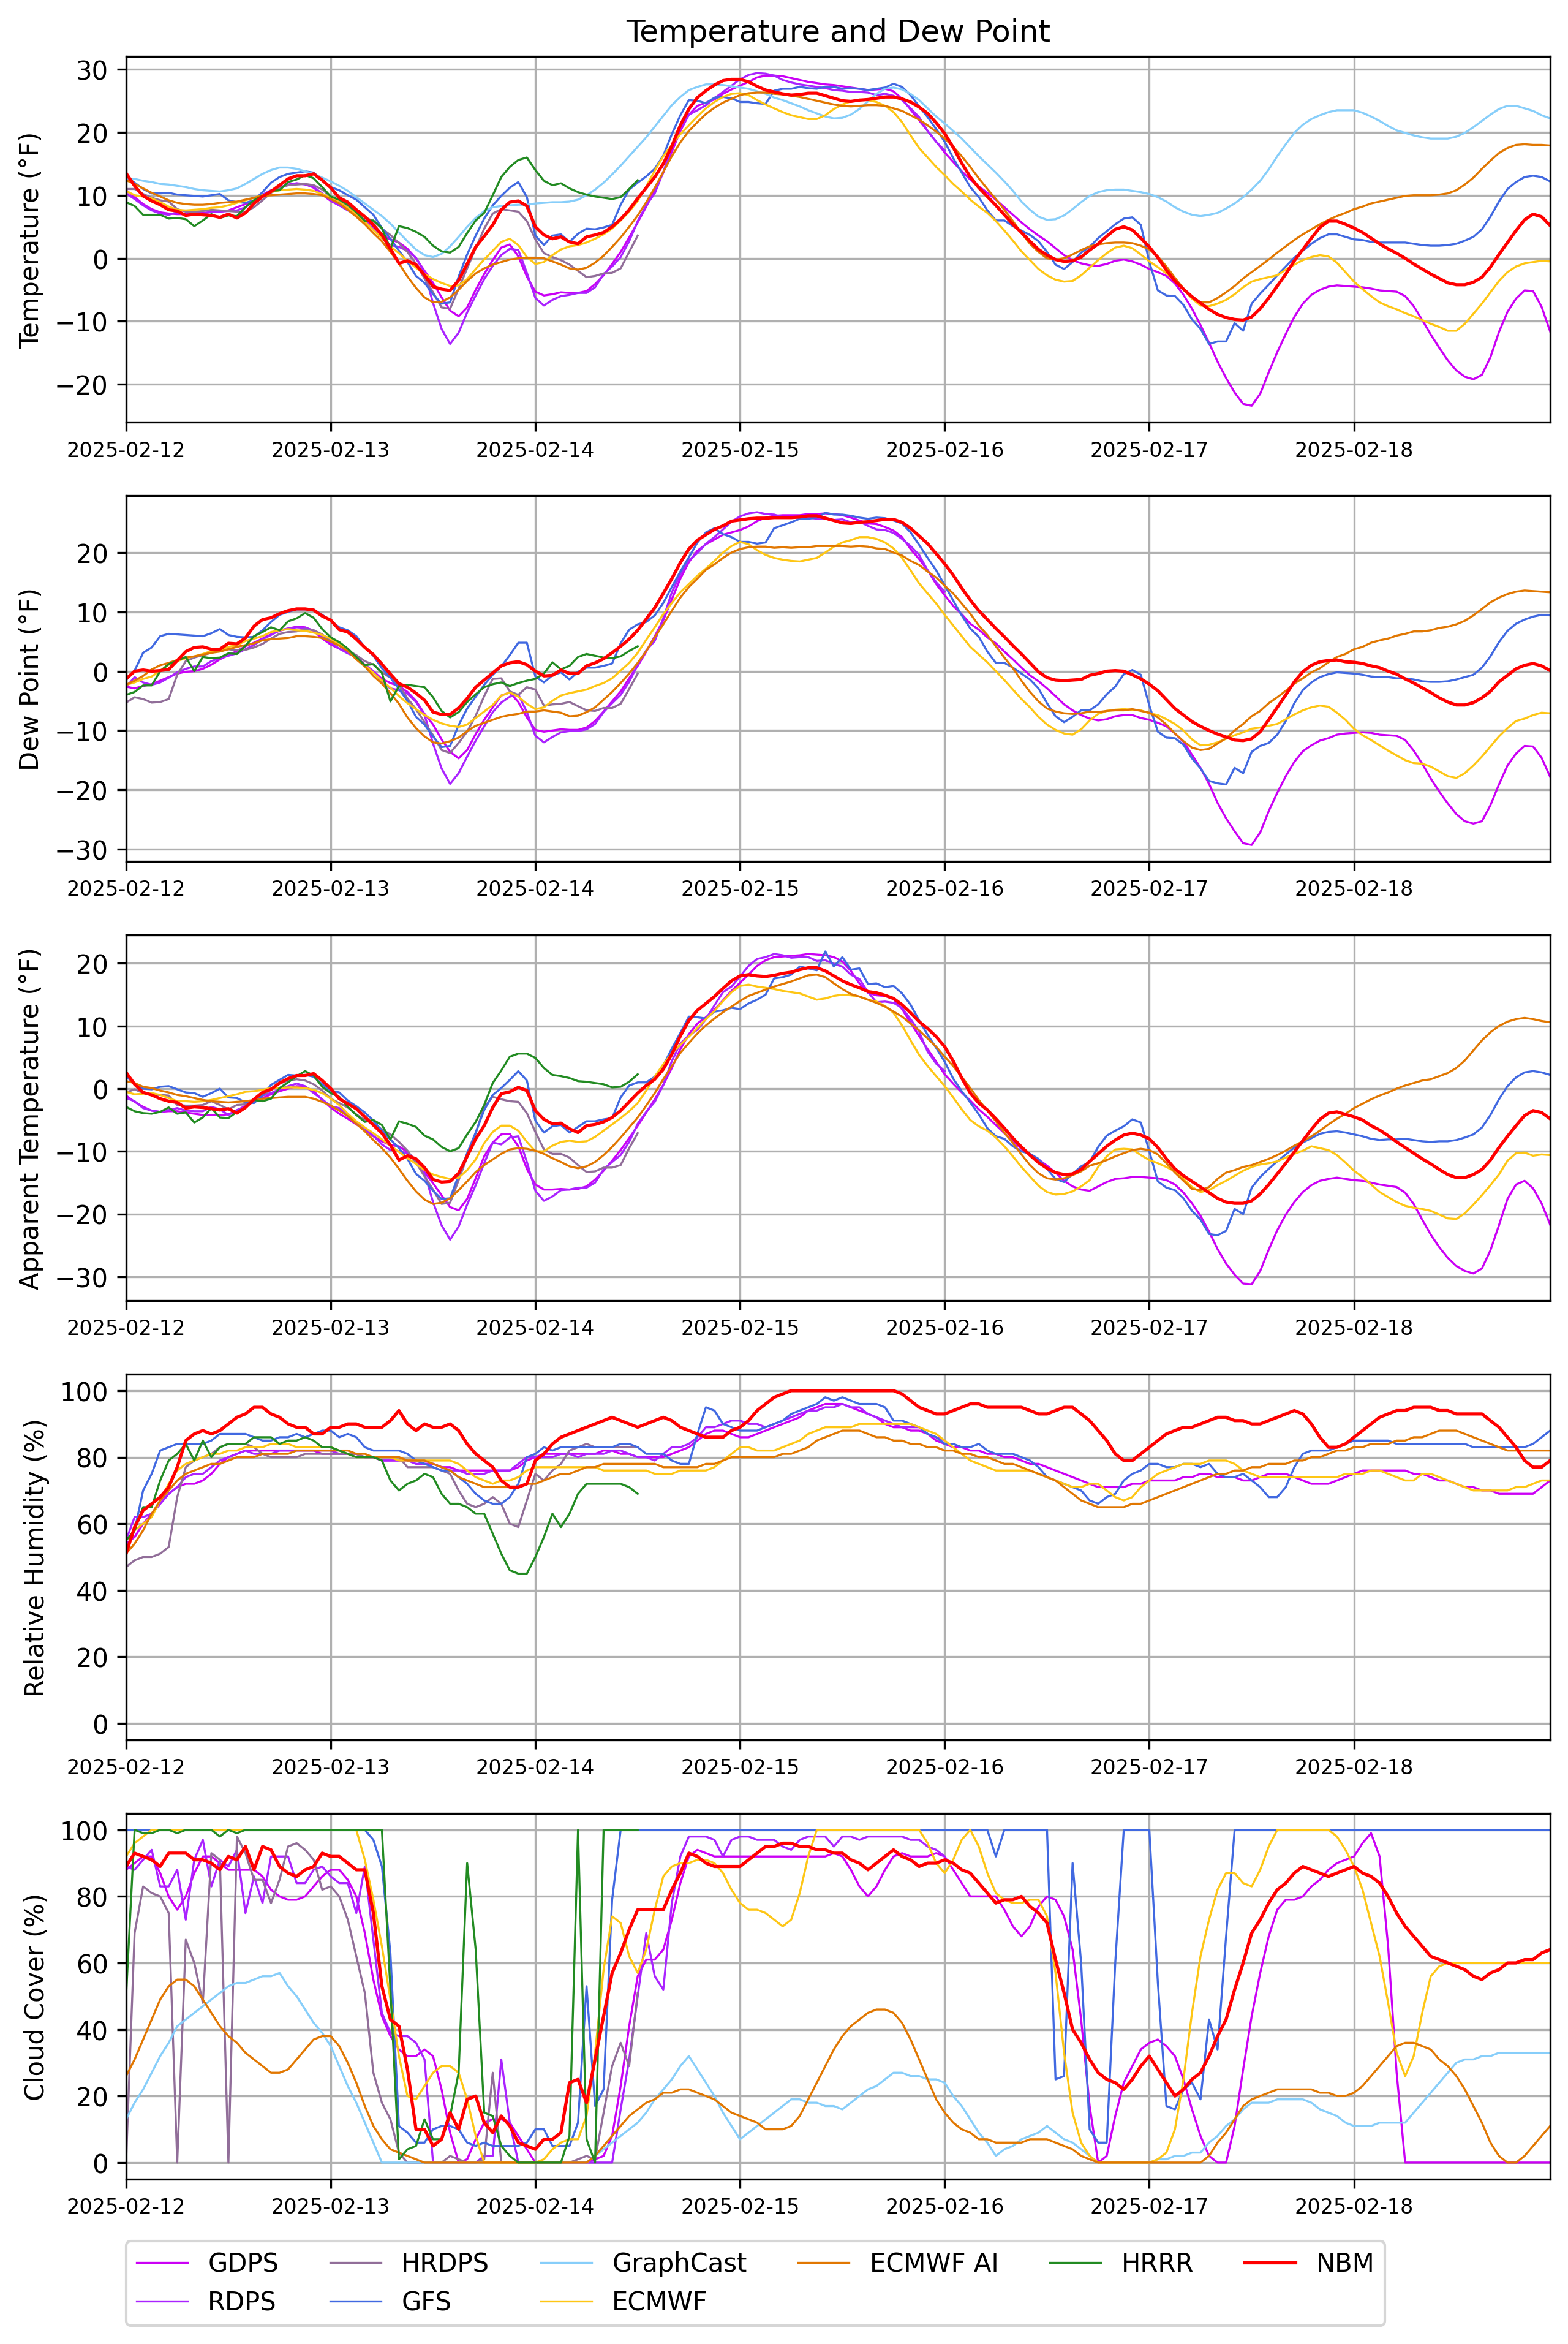

In [15]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["xtick.labelsize"] = 8
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, figsize=(10,15))

# Plots 2-meter air temperatures.
ax1.plot(GDPSdataframe[timeName], GDPSdataframe[temperatureName], color=GDPScolor, linewidth=linewidth)
ax1.plot(RDPSdataframe[timeName], RDPSdataframe[temperatureName], color=RDPScolor, linewidth=linewidth)
ax1.plot(HRDPSdataframe[timeName], HRDPSdataframe[temperatureName], color=HRDPScolor, linewidth=linewidth)
ax1.plot(GFSdataframe[timeName], GFSdataframe[temperatureName], color=GFScolor, linewidth=linewidth)
ax1.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[temperatureName], color=GFS_GCcolor, linewidth=linewidth)
ax1.plot(ECMWFdataframe[timeName], ECMWFdataframe[temperatureName], color=ECMWFcolor, linewidth=linewidth)
ax1.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[temperatureName], color=ECMWF_AIcolor, linewidth=linewidth)
ax1.plot(HRRRdataframe[timeName], HRRRdataframe[temperatureName], color=HRRRcolor, linewidth=linewidth)
ax1.plot(NBMdataframe[timeName], NBMdataframe[temperatureName], color=NBMcolor, linewidth=NBMlinewidth)

# Plots 2-meter dew point temperatures.
# Some models (GFS-GC) lack dew point information.
ax2.plot(GDPSdataframe[timeName], GDPSdataframe[dewpointName], color=GDPScolor, linewidth=linewidth)
ax2.plot(RDPSdataframe[timeName], RDPSdataframe[dewpointName], color=RDPScolor, linewidth=linewidth)
ax2.plot(HRDPSdataframe[timeName], HRDPSdataframe[dewpointName], color=HRDPScolor, linewidth=linewidth)
ax2.plot(GFSdataframe[timeName], GFSdataframe[dewpointName], color=GFScolor, linewidth=linewidth)
#ax2.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[dewpointName], color=GFS_GCcolor, linewidth=linewidth)
ax2.plot(ECMWFdataframe[timeName], ECMWFdataframe[dewpointName], color=ECMWFcolor, linewidth=linewidth)
ax2.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[dewpointName], color=ECMWF_AIcolor, linewidth=linewidth)
ax2.plot(HRRRdataframe[timeName],HRRRdataframe[dewpointName], color=HRRRcolor, linewidth=linewidth)
ax2.plot(NBMdataframe[timeName], NBMdataframe[dewpointName], color=NBMcolor, linewidth=NBMlinewidth)

# Plots 2-meter apparent ("feels like") temperatures.
# Some models (GFS-GC) lack apparent temperature information.
ax3.plot(GDPSdataframe[timeName], GDPSdataframe[feelsLikeName], color=GDPScolor, linewidth=linewidth)
ax3.plot(RDPSdataframe[timeName], RDPSdataframe[feelsLikeName], color=RDPScolor, linewidth=linewidth)
ax3.plot(HRDPSdataframe[timeName], HRDPSdataframe[feelsLikeName], color=HRDPScolor, linewidth=linewidth)
ax3.plot(GFSdataframe[timeName], GFSdataframe[feelsLikeName], color=GFScolor, linewidth=linewidth)
ax3.plot(ECMWFdataframe[timeName], ECMWFdataframe[feelsLikeName], color=ECMWFcolor, linewidth=linewidth)
ax3.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[feelsLikeName], color=ECMWF_AIcolor, linewidth=linewidth)
ax3.plot(HRRRdataframe[timeName], HRRRdataframe[feelsLikeName], color=HRRRcolor, linewidth=linewidth)
ax3.plot(NBMdataframe[timeName], NBMdataframe[feelsLikeName], color=NBMcolor, linewidth=NBMlinewidth)

# Plots 2-meter relative humidities.
# Some models (GFS-GC) lack relative humidity information.
ax4.plot(GDPSdataframe[timeName], GDPSdataframe[rhName], color=GDPScolor, linewidth=linewidth)
ax4.plot(RDPSdataframe[timeName], RDPSdataframe[rhName], color=RDPScolor, linewidth=linewidth)
ax4.plot(HRDPSdataframe[timeName], HRDPSdataframe[rhName], color=HRDPScolor, linewidth=linewidth)
ax4.plot(GFSdataframe[timeName], GFSdataframe[rhName], color=GFScolor, linewidth=linewidth)
ax4.plot(ECMWFdataframe[timeName], ECMWFdataframe[rhName], color=ECMWFcolor, linewidth=linewidth)
ax4.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[rhName], color=ECMWF_AIcolor, linewidth=linewidth)
ax4.plot(HRRRdataframe[timeName], HRRRdataframe[rhName], color=HRRRcolor, linewidth=linewidth)
ax4.plot(NBMdataframe[timeName], NBMdataframe[rhName], color=NBMcolor, linewidth=NBMlinewidth)

# Plots total cloud cover data.
ax5.plot(GDPSdataframe[timeName], GDPSdataframe[cloudCoverName], color=GDPScolor, linewidth=linewidth, label="GDPS")
ax5.plot(RDPSdataframe[timeName], RDPSdataframe[cloudCoverName], color=RDPScolor, linewidth=linewidth, label="RDPS")
ax5.plot(HRDPSdataframe[timeName], HRDPSdataframe[cloudCoverName], color=HRDPScolor, linewidth=linewidth, label="HRDPS")
ax5.plot(GFSdataframe[timeName], GFSdataframe[cloudCoverName], color=GFScolor, linewidth=linewidth, label="GFS")
ax5.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[cloudCoverName], color=GFS_GCcolor, linewidth=linewidth, label="GraphCast")
ax5.plot(ECMWFdataframe[timeName], ECMWFdataframe[cloudCoverName], color=ECMWFcolor, linewidth=linewidth, label="ECMWF")
ax5.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[cloudCoverName], color=ECMWF_AIcolor, linewidth=linewidth, label="ECMWF AI")
ax5.plot(HRRRdataframe[timeName], HRRRdataframe[cloudCoverName], color=HRRRcolor, linewidth=linewidth, label="HRRR")
ax5.plot(NBMdataframe[timeName], NBMdataframe[cloudCoverName], color=NBMcolor, linewidth=NBMlinewidth, label="NBM")

# Enables gridding.
ax1.grid(True)
ax2.grid(True)
ax3.grid(True)
ax4.grid(True)
ax5.grid(True)

# Sets y-labels and title.
ax1.set_title("Temperature and Dew Point")
ax1.set_ylabel("Temperature (°F)")
ax2.set_ylabel("Dew Point (°F)")
ax3.set_ylabel("Apparent Temperature (°F)")
ax4.set_ylabel("Relative Humidity (%)")
ax5.set_ylabel("Cloud Cover (%)")

# Adjust the bounds of the plot to make it consistent.
plt.setp(ax1, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax2, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax3, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax4, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]], ylim=[-5, 105])
plt.setp(ax5, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]], ylim=[-5, 105])

# Sets the legend and size of it.
leg = ax5.legend(loc=(0, -0.4), ncol=6)

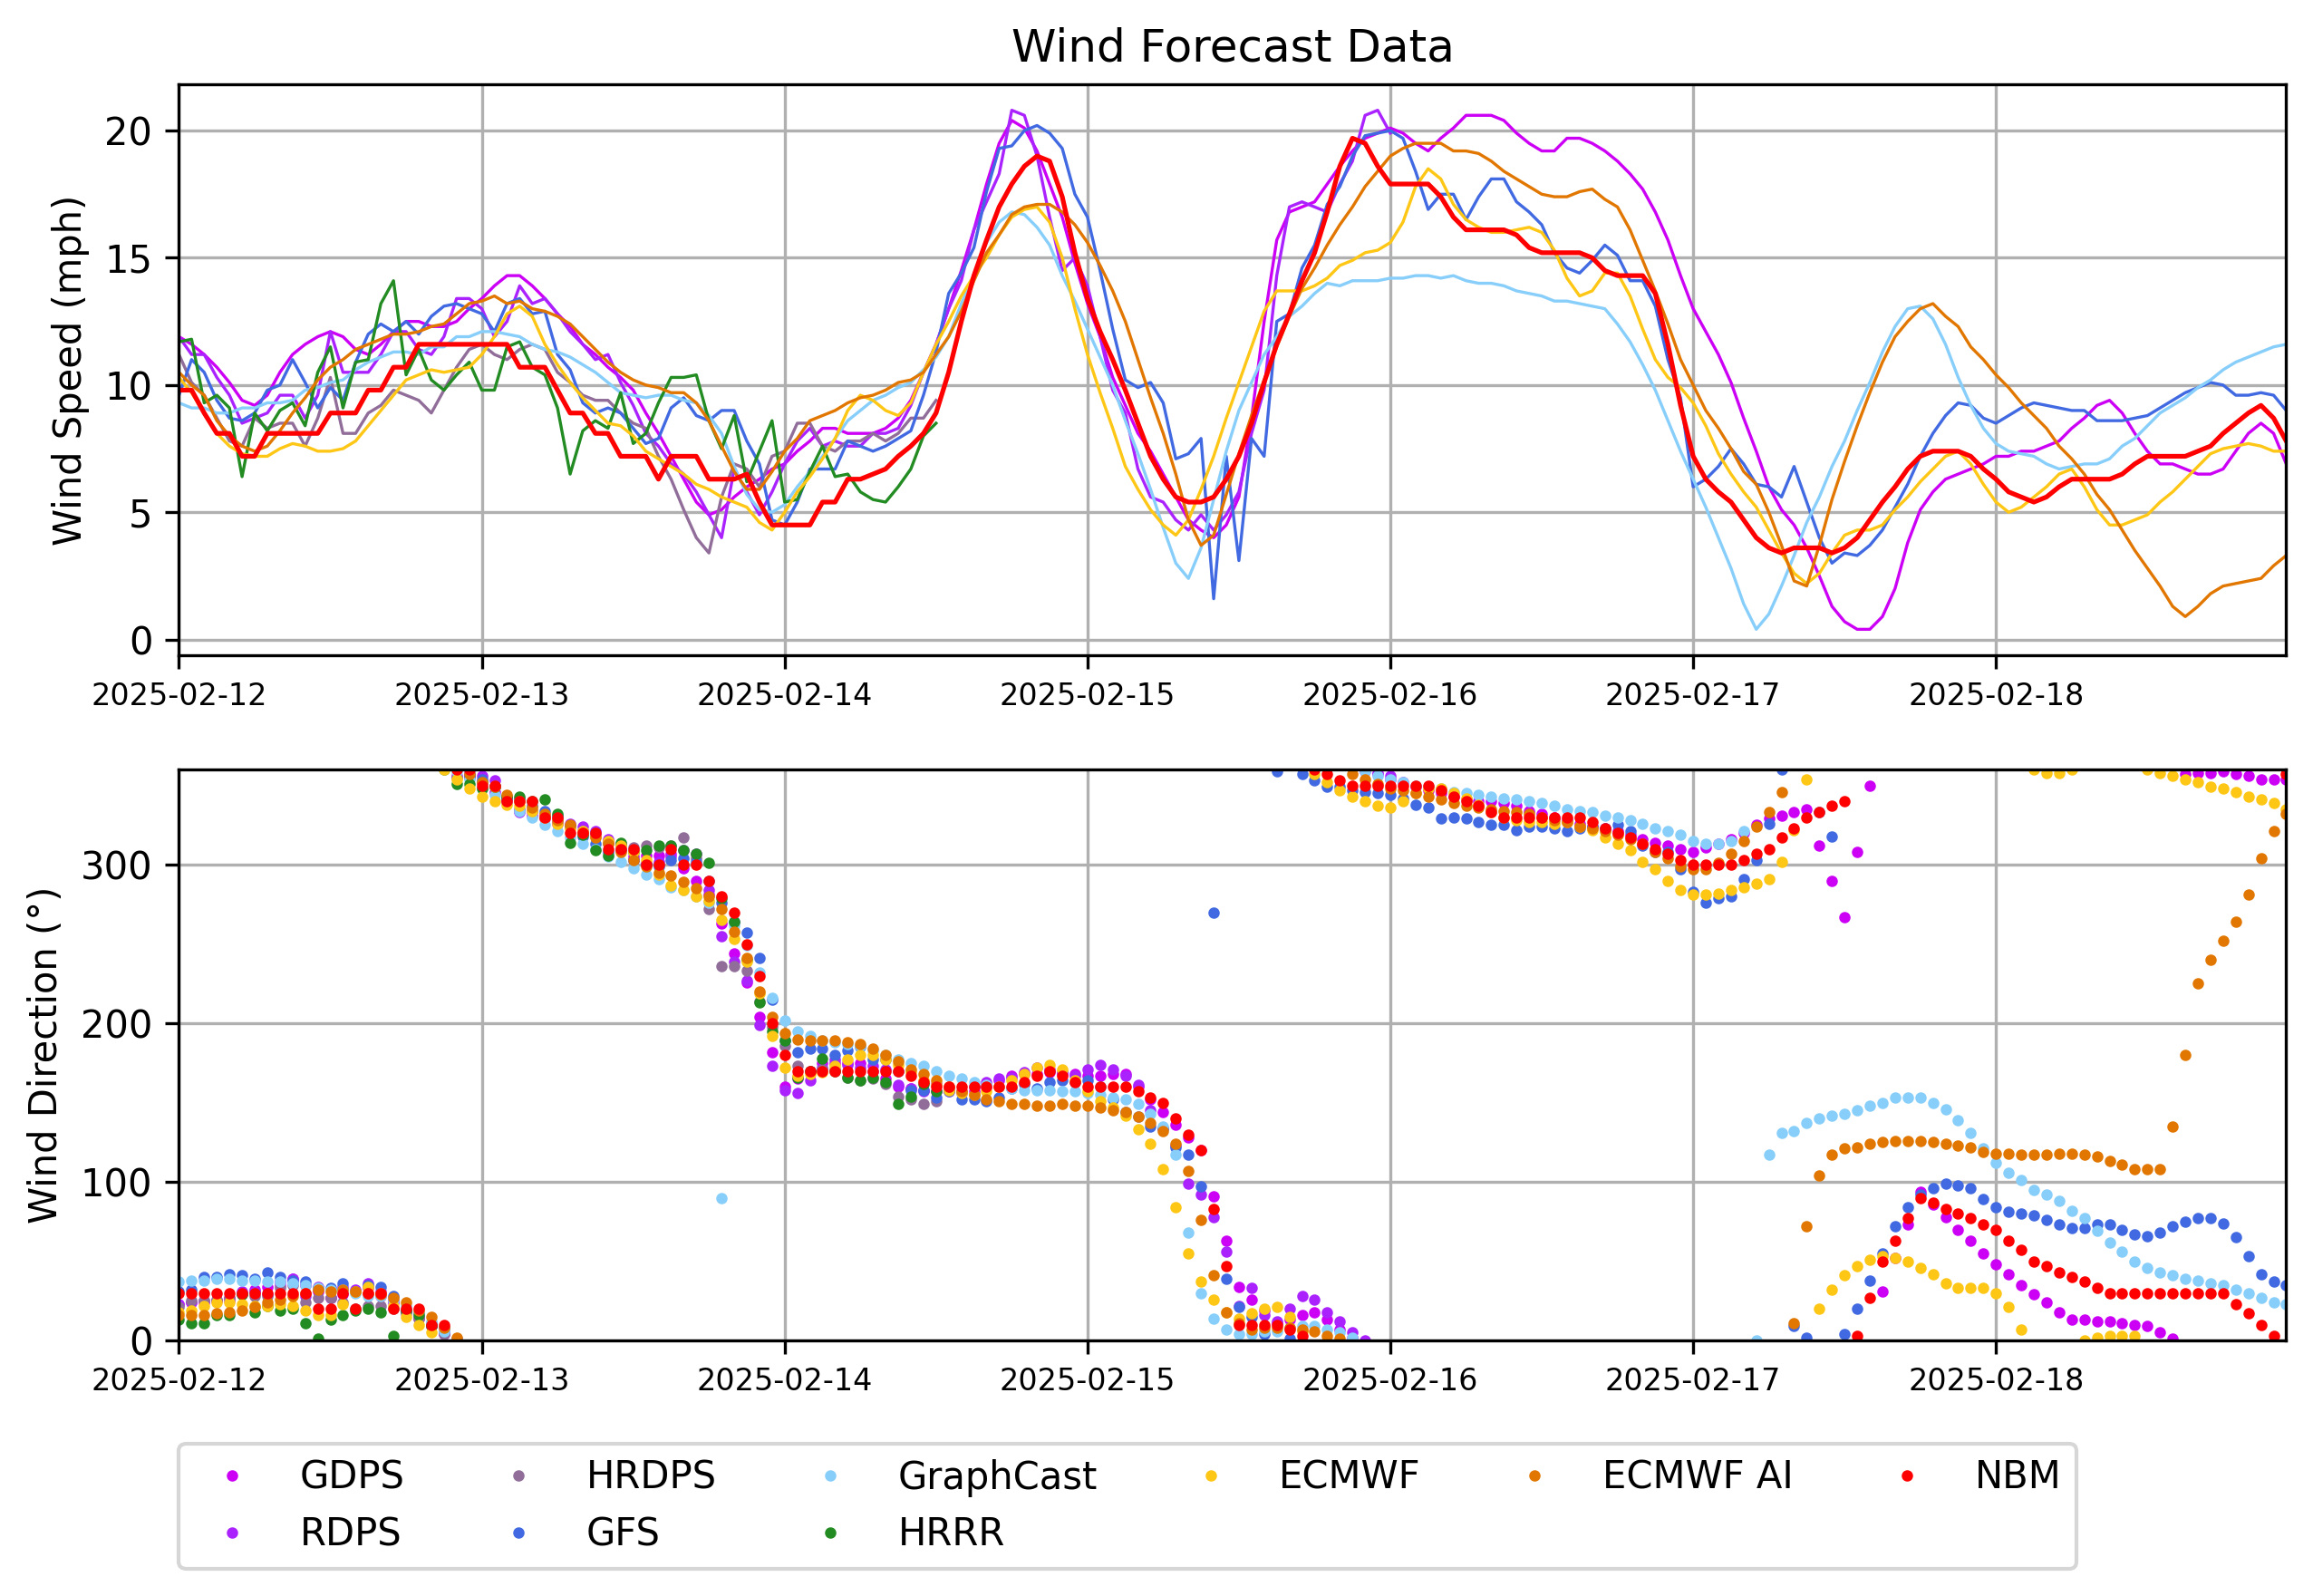

In [16]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["xtick.labelsize"] = 8
fig, (ax1, ax2) = plt.subplots(2, figsize=(10,6))

ax1.plot(GDPSdataframe[timeName], GDPSdataframe[windSpeedName], color=GDPScolor, linewidth=linewidth)
ax1.plot(RDPSdataframe[timeName], RDPSdataframe[windSpeedName], color=RDPScolor, linewidth=linewidth)
ax1.plot(HRDPSdataframe[timeName], HRDPSdataframe[windSpeedName], color=HRDPScolor, linewidth=linewidth)
ax1.plot(GFSdataframe[timeName], GFSdataframe[windSpeedName], color=GFScolor, linewidth=linewidth)
ax1.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[windSpeedName], color=GFS_GCcolor, linewidth=linewidth)
ax1.plot(HRRRdataframe[timeName], HRRRdataframe[windSpeedName], color=HRRRcolor, linewidth=linewidth)
ax1.plot(ECMWFdataframe[timeName], ECMWFdataframe[windSpeedName], color=ECMWFcolor, linewidth=linewidth)
ax1.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[windSpeedName], color=ECMWF_AIcolor, linewidth=linewidth)
ax1.plot(NBMdataframe[timeName], NBMdataframe[windSpeedName], color=NBMcolor, linewidth=NBMlinewidth)

markerStyle = dict(marker='.', markersize=4, linewidth=0)
ax2.plot(GDPSdataframe[timeName], GDPSdataframe[windDirName], color=GDPScolor, **markerStyle, label="GDPS")
ax2.plot(RDPSdataframe[timeName], RDPSdataframe[windDirName], color=RDPScolor, **markerStyle, label="RDPS")
ax2.plot(HRDPSdataframe[timeName], HRDPSdataframe[windDirName], color=HRDPScolor, **markerStyle, label="HRDPS")
ax2.plot(GFSdataframe[timeName], GFSdataframe[windDirName], color=GFScolor, **markerStyle, label="GFS")
ax2.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[windDirName], color=GFS_GCcolor, **markerStyle, label="GraphCast")
ax2.plot(HRRRdataframe[timeName], HRRRdataframe[windDirName], color=HRRRcolor, **markerStyle, label="HRRR")
ax2.plot(ECMWFdataframe[timeName], ECMWFdataframe[windDirName], color=ECMWFcolor, **markerStyle, label="ECMWF")
ax2.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[windDirName], color=ECMWF_AIcolor, **markerStyle, label="ECMWF AI")
ax2.plot(NBMdataframe[timeName], NBMdataframe[windDirName], color=NBMcolor, **markerStyle, label="NBM")

ax1.grid(True)
ax2.grid(True)

ax1.set_title("Wind Forecast Data")
ax1.set_ylabel("Wind Speed (mph)")
ax2.set_ylabel("Wind Direction (°)")

plt.setp(ax1, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax2, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]], ylim=[0, 360])

leg = ax2.legend(loc=(0, -0.4), ncol=6)

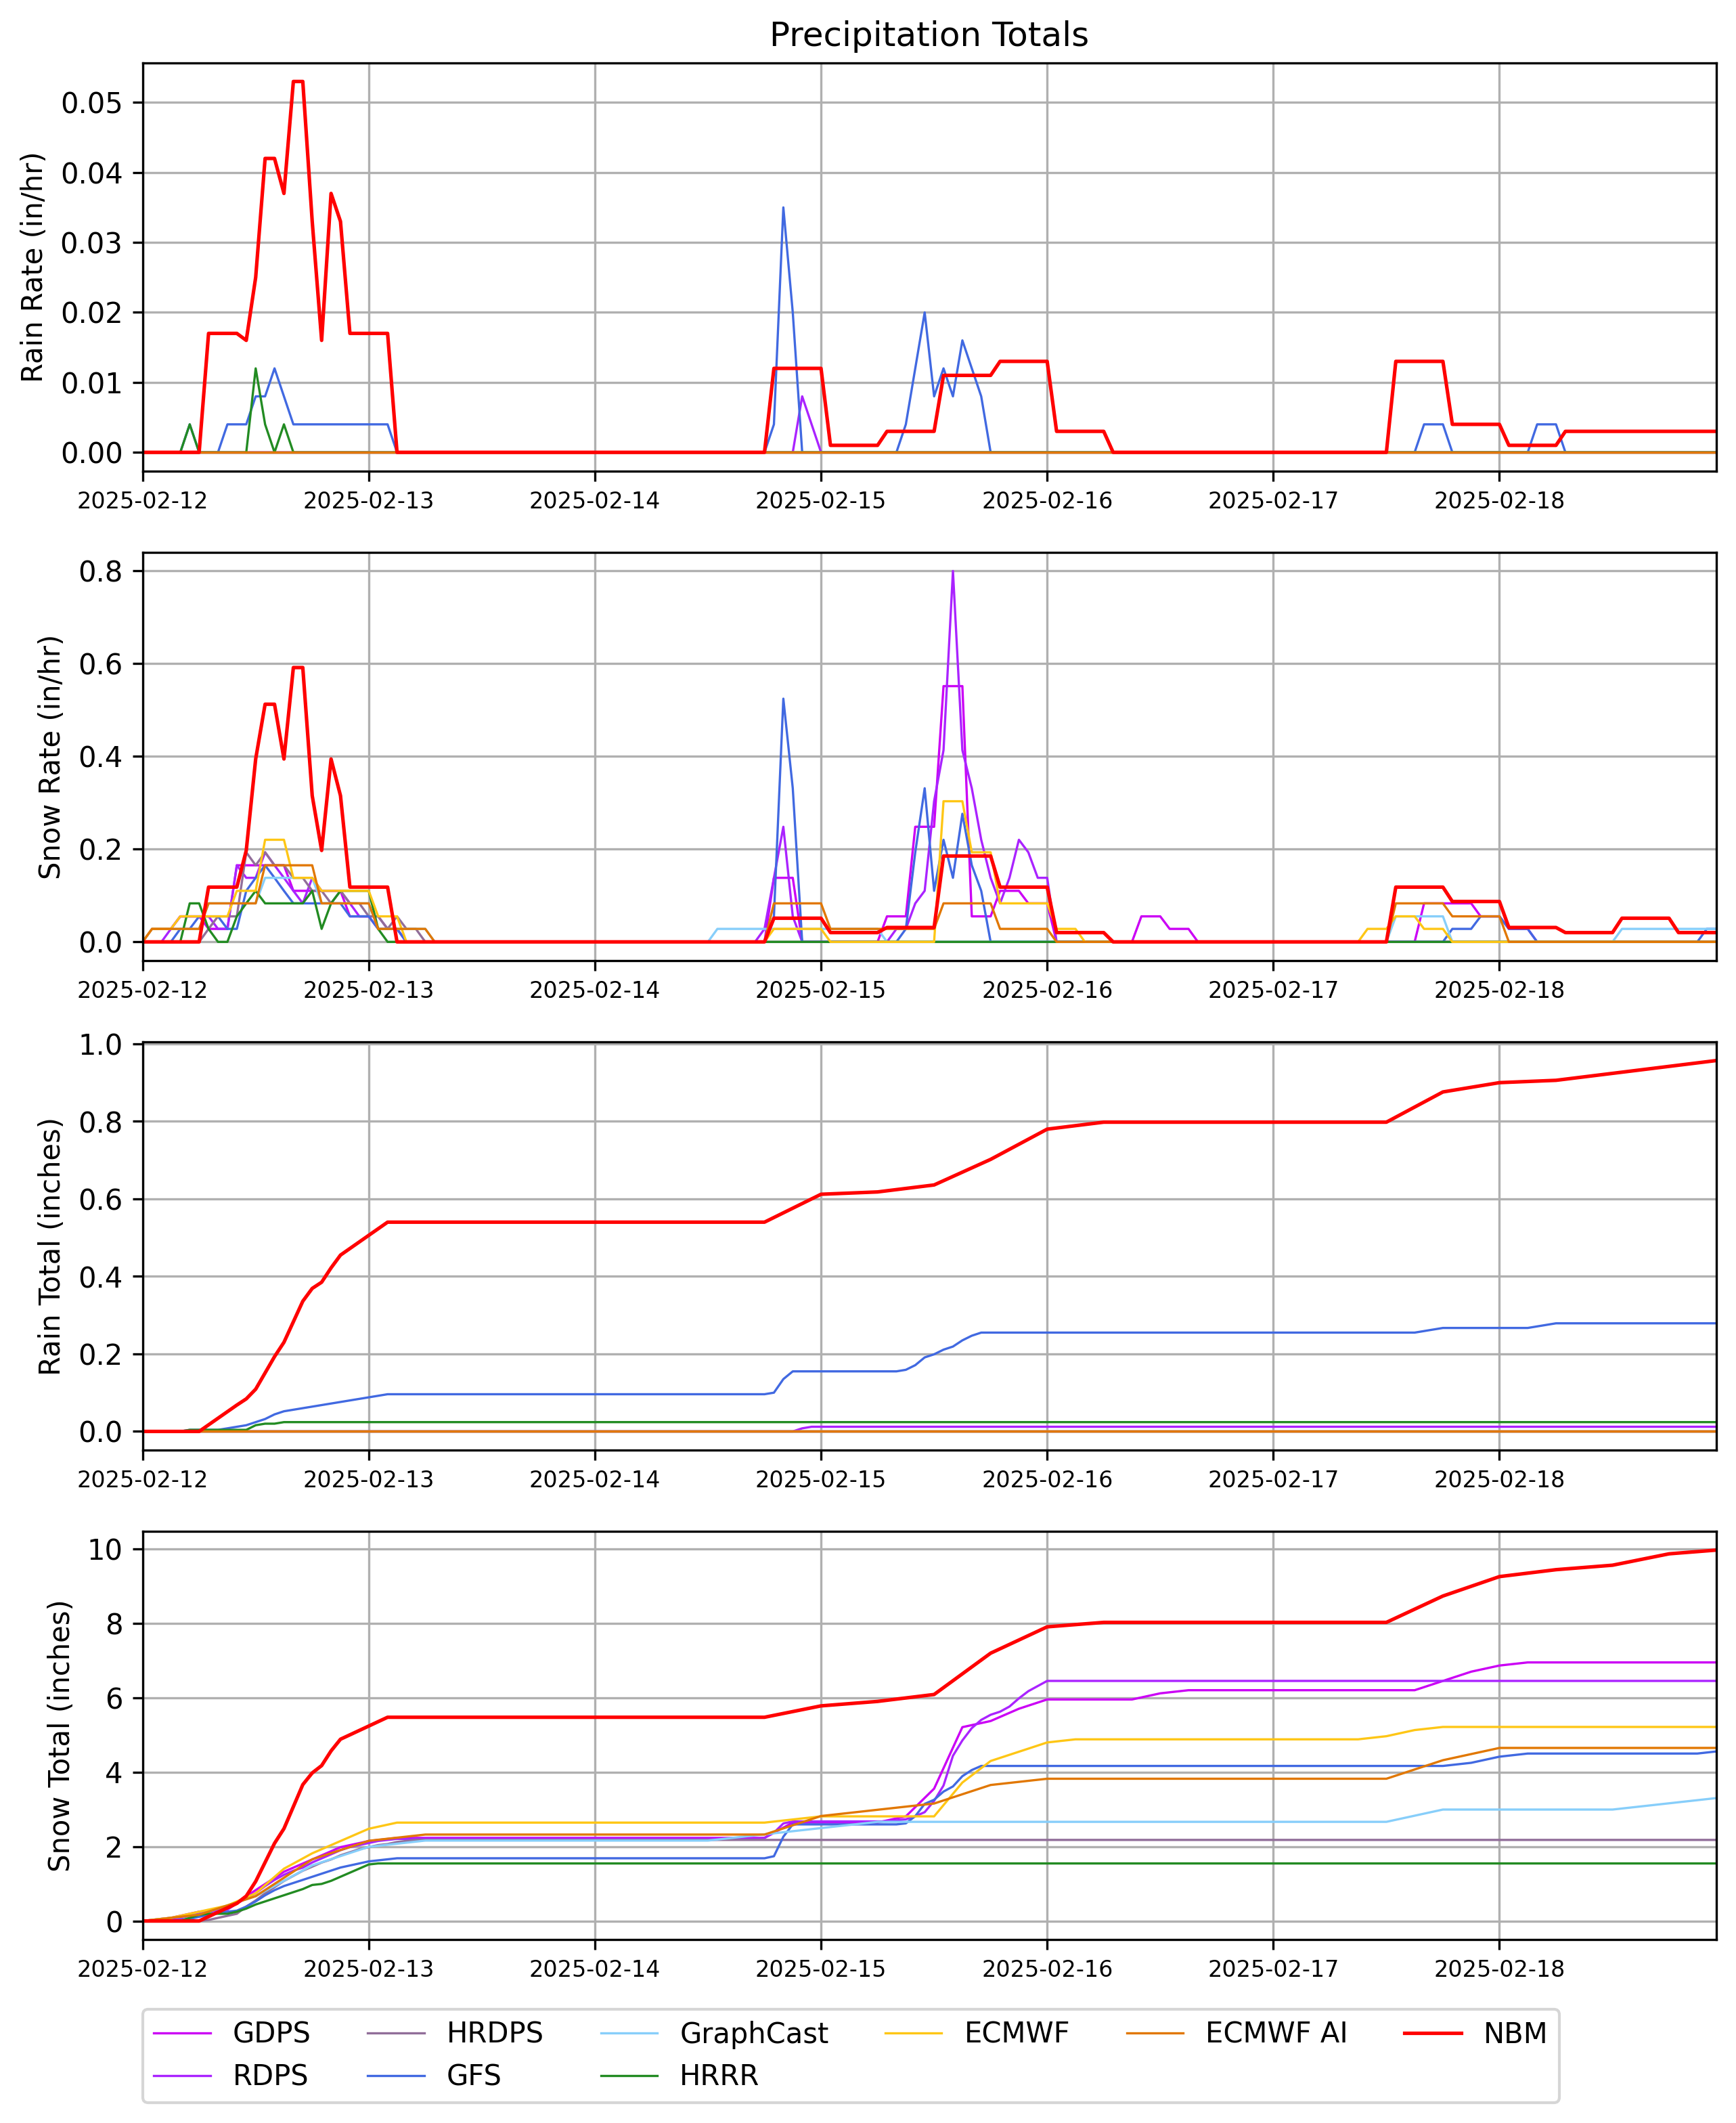

In [17]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["xtick.labelsize"] = 8
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize=(10,12))

ax1.plot(GDPSdataframe[timeName], GDPSdataframe[rainName], color=GDPScolor, linewidth=linewidth)
ax1.plot(RDPSdataframe[timeName], RDPSdataframe[rainName], color=RDPScolor, linewidth=linewidth)
ax1.plot(HRDPSdataframe[timeName], HRDPSdataframe[rainName], color=HRDPScolor, linewidth=linewidth)
ax1.plot(GFSdataframe[timeName], GFSdataframe[rainName], color=GFScolor, linewidth=linewidth)
ax1.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[rainName], color=GFS_GCcolor, linewidth=linewidth)
ax1.plot(HRRRdataframe[timeName], HRRRdataframe[rainName], color=HRRRcolor, linewidth=linewidth)
ax1.plot(ECMWFdataframe[timeName], ECMWFdataframe[rainName], color=ECMWFcolor, linewidth=linewidth)
ax1.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[rainName], color=ECMWF_AIcolor, linewidth=linewidth)
ax1.plot(NBMdataframe[timeName], NBMdataframe[rainName], color=NBMcolor, linewidth=NBMlinewidth)

ax2.plot(GDPSdataframe[timeName], GDPSdataframe[snowName], color=GDPScolor, linewidth=linewidth)
ax2.plot(RDPSdataframe[timeName], RDPSdataframe[snowName], color=RDPScolor, linewidth=linewidth)
ax2.plot(HRDPSdataframe[timeName], HRDPSdataframe[snowName], color=HRDPScolor, linewidth=linewidth)
ax2.plot(GFSdataframe[timeName], GFSdataframe[snowName], color=GFScolor, linewidth=linewidth)
ax2.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[snowName], color=GFS_GCcolor, linewidth=linewidth)
ax2.plot(HRRRdataframe[timeName], HRRRdataframe[snowName], color=HRRRcolor, linewidth=linewidth)
ax2.plot(ECMWFdataframe[timeName], ECMWFdataframe[snowName], color=ECMWFcolor, linewidth=linewidth)
ax2.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[snowName], color=ECMWF_AIcolor, linewidth=linewidth)
ax2.plot(NBMdataframe[timeName], NBMdataframe[snowName], color=NBMcolor, linewidth=NBMlinewidth)

ax3.plot(GDPSdataframe[timeName], GDPSdataframe[rainTotalName], color=GDPScolor, linewidth=linewidth)
ax3.plot(RDPSdataframe[timeName], RDPSdataframe[rainTotalName], color=RDPScolor, linewidth=linewidth)
ax3.plot(HRDPSdataframe[timeName], HRDPSdataframe[rainTotalName], color=HRDPScolor, linewidth=linewidth)
ax3.plot(GFSdataframe[timeName], GFSdataframe[rainTotalName], color=GFScolor, linewidth=linewidth)
ax3.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[rainTotalName], color=GFS_GCcolor, linewidth=linewidth)
ax3.plot(HRRRdataframe[timeName], HRRRdataframe[rainTotalName], color=HRRRcolor, linewidth=linewidth)
ax3.plot(ECMWFdataframe[timeName], ECMWFdataframe[rainTotalName], color=ECMWFcolor, linewidth=linewidth)
ax3.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[rainTotalName], color=ECMWF_AIcolor, linewidth=linewidth)
ax3.plot(NBMdataframe[timeName], NBMdataframe[rainTotalName], color=NBMcolor, linewidth=NBMlinewidth)

ax4.plot(GDPSdataframe[timeName], GDPSdataframe[snowTotalName], color=GDPScolor, linewidth=linewidth, label="GDPS")
ax4.plot(RDPSdataframe[timeName], RDPSdataframe[snowTotalName], color=RDPScolor, linewidth=linewidth, label="RDPS")
ax4.plot(HRDPSdataframe[timeName], HRDPSdataframe[snowTotalName], color=HRDPScolor, linewidth=linewidth, label="HRDPS")
ax4.plot(GFSdataframe[timeName], GFSdataframe[snowTotalName], color=GFScolor, linewidth=linewidth, label="GFS")
ax4.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[snowTotalName], color=GFS_GCcolor, linewidth=linewidth, label="GraphCast")
ax4.plot(HRRRdataframe[timeName], HRRRdataframe[snowTotalName], color=HRRRcolor, linewidth=linewidth, label="HRRR")
ax4.plot(ECMWFdataframe[timeName], ECMWFdataframe[snowTotalName], color=ECMWFcolor, linewidth=linewidth, label="ECMWF")
ax4.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[snowTotalName], color=ECMWF_AIcolor, linewidth=linewidth, label="ECMWF AI")
ax4.plot(NBMdataframe[timeName], NBMdataframe[snowTotalName], color=NBMcolor, linewidth=NBMlinewidth, label="NBM")


ax1.grid(True)
ax2.grid(True)
ax3.grid(True)
ax4.grid(True)

ax1.set_title("Precipitation Totals")
ax1.set_ylabel("Rain Rate (in/hr)")
ax2.set_ylabel("Snow Rate (in/hr)")
ax3.set_ylabel("Rain Total (inches)")
ax4.set_ylabel("Snow Total (inches)")

plt.setp(ax1, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax2, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax3, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax4, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])

leg = ax4.legend(loc=(0, -0.4), ncol=6)